# Data Collection
This section covers how we collected the Weather data using the WeatherAPI (https://www.weatherapi.com/)



### Set-Up Code
Setting up the key to pull weather data from the API

In [ ]:
# Replace 'your_api_key_here' with your actual WeatherAPI key
api_key = 'your_api_key_here '
location = 'Victoria, BC'

### API Call
In this code chunk we call the API and preview the data


In [ ]:
import requests
import json
from datetime import datetime

def extract_preview_data(data, target_time):
    """
    Extracts a portion of the JSON data up to and including the specified target time.
    This is done because the weatherAPI returns hour per hour weather data meaing just printing the JSON would take up too much space

    Args:
    - data (dict): The JSON data containing weather forecast information.
    - target_time (str): The target time in the format 'YYYY-MM-DD HH:MM'.

    Returns:
    - dict: A subset of the JSON data containing information up to and including the specified target time.
    """
    preview_data = {
        'location': data['location'],
        'forecast': {
            'forecastday': [
                {
                    'date': forecast['date'],
                    'date_epoch': forecast['date_epoch'],
                    'day': forecast['day'],
                    'astro': forecast['astro'],
                    'hour': [hour for hour in forecast['hour'] if hour['time'] <= target_time]
                } for forecast in data['forecast']['forecastday']
            ]
        }
    }
    return preview_data


date = '2023-03-26'  # Example date in YYYY-MM-DD format

# Constructing the URL for the historical weather data
url = f'http://api.weatherapi.com/v1/history.json?key={api_key}&q={location}&dt={date}'

# Making the request
response = requests.get(url)

# Checking if the request was successful
if response.status_code == 200:
    data = response.json()

    # Incase you want to look at the full JSON data
    #print(json.dumps(data, indent=2))

    # Specify the target time for preview
    target_time = '2023-03-26 00:00'

    # Extract the preview data using the function
    preview_data = extract_preview_data(data, target_time)

    # Print the formatted preview JSON data
    preview_json_str = json.dumps(preview_data, indent=2)
    print("Preview of the JSON data up to and including the hour " + target_time + ":")
    print(preview_json_str)
else:
    print("Failed to retrieve data:", response.status_code)

Preview of the JSON data up to and including the hour 2023-03-26 00:00:
{
  "location": {
    "name": "Victoria",
    "region": "British Columbia",
    "country": "Canada",
    "lat": 48.43,
    "lon": -123.35,
    "tz_id": "America/Vancouver",
    "localtime_epoch": 1711394234,
    "localtime": "2024-03-25 12:17"
  },
  "forecast": {
    "forecastday": [
      {
        "date": "2023-03-26",
        "date_epoch": 1679788800,
        "day": {
          "maxtemp_c": 7.3,
          "maxtemp_f": 45.1,
          "mintemp_c": 1.7,
          "mintemp_f": 35.1,
          "avgtemp_c": 3.8,
          "avgtemp_f": 38.8,
          "maxwind_mph": 6.3,
          "maxwind_kph": 10.1,
          "totalprecip_mm": 0.0,
          "totalprecip_in": 0.0,
          "totalsnow_cm": 0.0,
          "avgvis_km": 9.9,
          "avgvis_miles": 6.0,
          "avghumidity": 80,
          "daily_will_it_rain": 0,
          "daily_chance_of_rain": 0,
          "daily_will_it_snow": 0,
          "daily_chance_of_sn

# Data Preprocessing
This section covers how we selected relevant data points from the API, cleaned it and transformed it into useful data

### Extracting Relevant Data
Here's a function extract only the desired data points from the JSON returned by the API call

In [ ]:
# Function to extract the desired data points
def extract_desired_data(data):
    extracted_data = [{
    "date": day['date'],
    **{
        key: value for key, value in day['day'].items() if key in [
            "mintemp_c", "maxtemp_c",
            "avgtemp_c", "maxwind_kph",
            "totalprecip_mm",
            "avgvis_km",  "avghumidity",
            "uv"
        ]
    }
  } for day in data['forecast']['forecastday']]

    return extracted_data

### Here we have to consider which data points from the large JSON file were relevant and useful to us.

Here are the attributes that are present in the JSON Data: <br>
### Location Information
- **name**: Name of the location
- **region**: Region where the location is situated
- **country**: Country of the location
- **lat**: Latitude coordinate
- **lon**: Longitude coordinate
- **tz_id**: Time zone identifier
- **localtime_epoch**: Local time in epoch format
- **localtime**: Human-readable local time

## Forecast Details
#### General Forecast
- **forecastday**: An array containing forecast information for one or more days.

#### Daily Forecast Structure
- **date**: The date of the forecast
- **date_epoch**: The epoch time of the forecast date
- **day**:
  - **maxtemp_c**: Maximum temperature in Celsius
  - **maxtemp_f**: Maximum temperature in Fahrenheit
  - **mintemp_c**: Minimum temperature in Celsius
  - **mintemp_f**: Minimum temperature in Fahrenheit
  - **avgtemp_c**: Average temperature in Celsius
  - **avgtemp_f**: Average temperature in Fahrenheit
  - **maxwind_mph**: Maximum wind speed in miles per hour
  - **maxwind_kph**: Maximum wind speed in kilometers per hour
  - **totalprecip_mm**: Total precipitation in millimeters
  - **totalprecip_in**: Total precipitation in inches
  - **totalsnow_cm**: Total snowfall in centimeters
  - **avgvis_km**: Average visibility in kilometers
  - **avgvis_miles**: Average visibility in miles
  - **avghumidity**: Average humidity percentage
  - **daily_will_it_rain**: Indicator if it will rain
  - **daily_chance_of_rain**: Chance of rain percentage
  - **daily_will_it_snow**: Indicator if it will snow
  - **daily_chance_of_snow**: Chance of snow percentage
  - **condition**:
    - **text**: Weather condition text
    - **icon**: URL to the weather condition icon
    - **code**: Weather condition code
  - **uv**: UV index
- **astro**:
  - **sunrise**: Sunrise time
  - **sunset**: Sunset time
  - **moonrise**: Moonrise time
  - **moonset**: Moonset time
  - **moon_phase**: Phase of the moon
  - **moon_illumination**: Illumination percentage of the moon
  
### Hourly Forecast Structure (within **hour** array)
- **time_epoch**: Time in epoch format
- **time**: Human-readable time
- **temp_c**: Temperature in Celsius
- **temp_f**: Temperature in Fahrenheit
- **is_day**: Indicator if it's day
- **condition**:
  - **text**: Weather condition text
  - **icon**: URL to the weather condition icon
  - **code**: Weather condition code
- **wind_mph**: Wind speed in miles per hour
- **wind_kph**: Wind speed in kilometers per hour
- **wind_degree**: Wind direction in degrees
- **wind_dir**: Wind direction as a string
- **pressure_mb**: Atmospheric pressure in millibars
- **pressure_in**: Atmospheric pressure in inches
- **precip_mm**: Precipitation in millimeters
- **precip_in**: Precipitation in inches
- **snow_cm**: Snowfall in centimeters
- **humidity**: Humidity percentage
- **cloud**: Cloud cover percentage
- **feelslike_c**: Feels like temperature in Celsius
- **feelslike_f**: Feels like temperature in Fahrenheit
- **windchill_c**: Wind chill temperature in Celsius
- **windchill_f**: Wind chill temperature in Fahrenheit
- **heatindex_c**: Heat index in Celsius
- **heatindex_f**: Heat index in Fahrenheit
- **dewpoint_c**: Dew point in Celsius
- **dewpoint_f**: Dew point in Fahrenheit
- **will_it_rain**: Indicator if it will rain
- **chance_of_rain**: Chance of rain percentage
- **will_it_snow**: Indicator if it will snow
- **chance_of_snow**: Chance of snow percentage
- **vis_km**: Visibility in kilometers
- **vis_miles**: Visibility in miles
- **gust_mph**: Wind gust speed in miles per hour
- **gust_kph**: Wind gust speed in kilometers per hour
- **uv**: UV index
<br> <br>
We selected some categories we thought could help predict "good weather" which in turn should predict high valence scores. Here's what we predicted based on our research with a little explantion into why.
 ### **Categories for "Good Weather":**
  1. **Maximum Temperature** (maxtemp_c):
     - High maximum temperature may indicate warm or hot weather, suitable for outdoor activities.
  2. **Minimum Temperature** (mintemp_c):
     - Comfortable minimum temperature could ensure pleasant conditions, especially during evenings and nights.
  3. **Average Temperature** (avgtemp_c):
     - Provides an overview of overall weather conditions throughout the day.
  4. **Total Precipitation** (totalprecip_mm):
     - Minimal precipitation is likely desirable, indicating drier conditions suitable for outdoor activities.
  5. **Maximum Wind Speed** (maxwind_kph):
     - Moderate maximum wind speed ensures outdoor activities are not disrupted by excessively strong winds.
  6. **Average Visibility** (avgvis_km):
     - Higher visibility values contribute to clearer skies and better outdoor visibility for activities like sightseeing or driving.
  7. **Average Humidity** (avghumidity):
     - Moderate humidity levels create a comfortable outdoor atmosphere without feeling overly dry or humid.
  8. **UV Index** (uv):
     - Moderate UV index balances sun exposure.


### Making the API call for relevant data
Now let generalize the API for our year long range of dates and process it using our function above to select the relevant data points

In [ ]:
import pandas as pd
import requests
import json
from datetime import datetime, timedelta

# Define start and end dates for the range
start_date = datetime(2023, 3, 26)
end_date = datetime(2024, 2, 26)

# Initialize an empty DataFrame to store all the extracted data
all_extracted_data = []

# Loop through each day in the range
current_date = start_date
while current_date <= end_date:
    # Constructing the URL for the historical weather data for the current date
    date_str = current_date.strftime('%Y-%m-%d')
    url = f'http://api.weatherapi.com/v1/history.json?key={api_key}&q={location}&dt={date_str}'

    # Making the request
    response = requests.get(url)

    # Checking if the request was successful
    if response.status_code == 200:
        extracted_data = extract_desired_data(response.json())
        all_extracted_data.append(extracted_data)
    else:
        print("Failed to retrieve data for", date_str, "Error:", response.status_code)

    # Move to the next day
    current_date += timedelta(days=1)

# Combine all extracted data into a single DataFrame
combined_data = pd.concat([pd.json_normalize(data) for data in all_extracted_data])

# Display the resulting DataFrame
print(combined_data)

          date  maxtemp_c  mintemp_c  avgtemp_c  maxwind_kph  totalprecip_mm  \
0   2023-03-26        7.3        1.7        3.8         10.1            0.00   
0   2023-03-27        9.8        1.8        5.3         11.5            0.00   
0   2023-03-28       11.8        3.9        7.1         23.4            0.00   
0   2023-03-29       12.1        3.0        7.1          9.7            0.00   
0   2023-03-30        9.5        3.0        6.6         13.3            0.00   
..         ...        ...        ...        ...          ...             ...   
0   2024-02-22       10.1        5.8        7.7          5.4            0.33   
0   2024-02-23        9.9        5.0        7.4         16.9            0.03   
0   2024-02-24        8.9        6.4        7.5         16.6            0.42   
0   2024-02-25        8.7        3.2        7.1         31.3            4.74   
0   2024-02-26        5.4        1.1        2.9         26.6            2.98   

    avgvis_km  avghumidity   uv  
0    

Finally let's save the data into a CSV file for future use and to pass between files more easily

In [ ]:
# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive') #give permissions

# Define the file path in Google Drive where you want to save the CSV file
file_path = '/content/drive/My Drive/combined_weather_data_final.csv'

# Save the combined data DataFrame to a CSV file in Google Drive
combined_data.to_csv(file_path, index=False)

# Print a message to confirm that the CSV file has been saved successfully
print("Combined weather data saved to", file_path)

Mounted at /content/drive
Combined weather data saved to /content/drive/My Drive/combined_weather_data_final.csv


# Data Visualization
Let's take a look at our data!


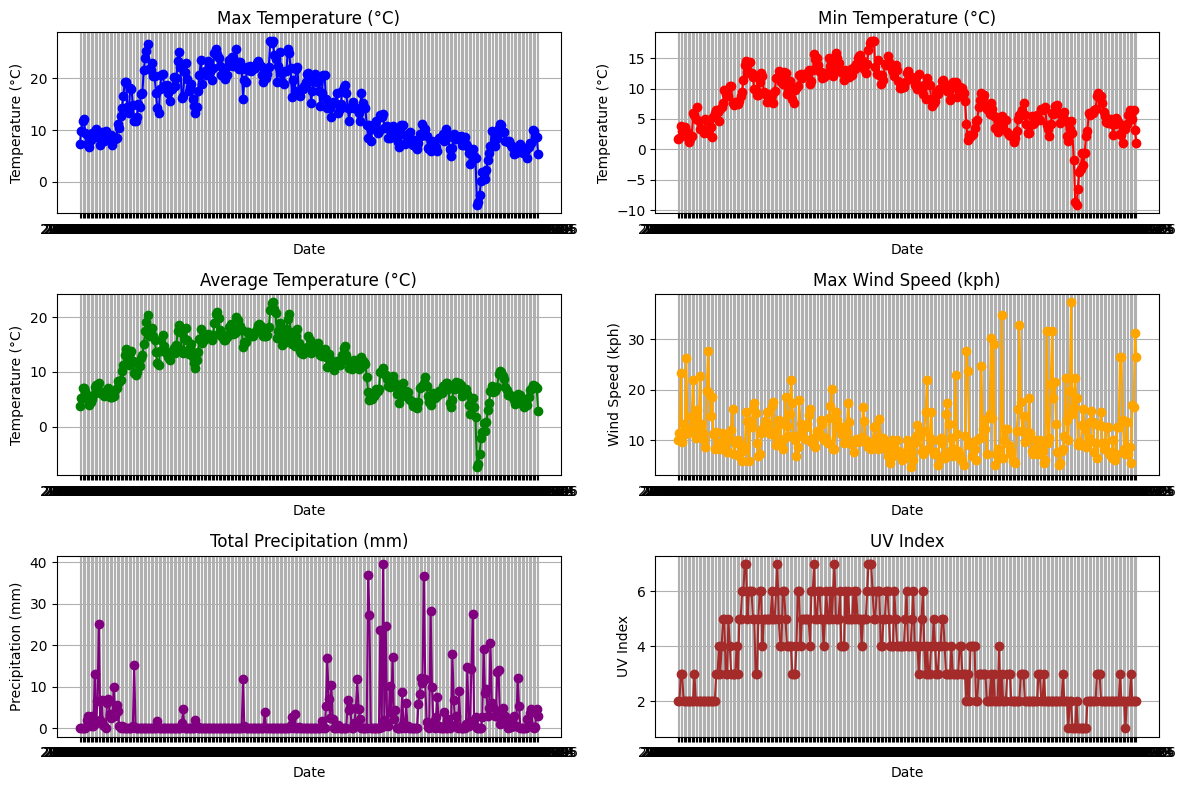

In [ ]:
import matplotlib.pyplot as plt

# Plotting
plt.figure(figsize=(12, 8))

# Max Temperature
plt.subplot(3, 2, 1)
plt.plot(combined_data['date'], combined_data['maxtemp_c'], marker='o', color='blue')
plt.title('Max Temperature (°C)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)

# Min Temperature
plt.subplot(3, 2, 2)
plt.plot(combined_data['date'], combined_data['mintemp_c'], marker='o', color='red')
plt.title('Min Temperature (°C)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)

# Average Temperature
plt.subplot(3, 2, 3)
plt.plot(combined_data['date'], combined_data['avgtemp_c'], marker='o', color='green')
plt.title('Average Temperature (°C)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)

# Max Wind Speed
plt.subplot(3, 2, 4)
plt.plot(combined_data['date'], combined_data['maxwind_kph'], marker='o', color='orange')
plt.title('Max Wind Speed (kph)')
plt.xlabel('Date')
plt.ylabel('Wind Speed (kph)')
plt.grid(True)

# Total Precipitation
plt.subplot(3, 2, 5)
plt.plot(combined_data['date'], combined_data['totalprecip_mm'], marker='o', color='purple')
plt.title('Total Precipitation (mm)')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')
plt.grid(True)

# UV Index
plt.subplot(3, 2, 6)
plt.plot(combined_data['date'], combined_data['uv'], marker='o', color='brown')
plt.title('UV Index')
plt.xlabel('Date')
plt.ylabel('UV Index')
plt.grid(True)

plt.tight_layout()
plt.show()

1.   **Max Temperature (°C):** This plot shows the maximum temperatures over time with blue markers. There's a clear periodic pattern, likely representing seasonal changes, with temperatures peaking in the middle and dropping at the edges, which could indicate summer and winter respectively.


2. **Min Temperature (°C):** This red plot tracks the minimum temperatures, and like the max temperature plot, it shows a seasonal pattern. The temperatures never drop below what appears to be -10°C, suggesting a relatively mild climate in terms of minimum temperatures.


3. **Average Temperature (°C):** The average temperature plot, in green, shows a smooth curve, following the max and min temperature trends. This gives a good indication of the overall temperature experience throughout the year.


4. **Max Wind Speed (kph):** The wind speed plot with orange markers is more variable without a clear seasonal pattern, which indicates that wind speeds might be influenced by short-term weather systems rather than seasonal trends.


5. **Total Precipitation (mm):** This purple plot represents precipitation and displays significant variation, with some peaks that might indicate heavy rainfall events. It doesn't show a clear seasonal pattern from this view, but there are periods with more frequent precipitation events.


6. **UV Index:** The UV index plot in red shows some seasonal trend with periods of higher values, likely corresponding to the months with higher sun angles and longer daylight hours.

In [ ]:
from pickle import FALSE
import seaborn as sns
plt.figure(figsize=(18, 12))

# Max Temperature, Min Temperature, Average Temperature (Line Plot)
# plt.subplot(2, 3, 1)
# plt.plot(combined_data['date'], combined_data['maxtemp_c'], marker='o', color='blue', label='Max Temp')
# plt.plot(combined_data['date'], combined_data['mintemp_c'], marker='o', color='red', label='Min Temp')
# plt.plot(combined_data['date'], combined_data['avgtemp_c'], marker='o', color='green', label='Avg Temp')
# plt.title('Temperature Trends')
# plt.xlabel('Date')
# plt.ylabel('Temperature (°C)')
# plt.legend()
# plt.grid(True)

# Max Wind Speed (Box Plot)
plt.subplot(2, 3, 2)
sns.boxplot(y=combined_data['maxwind_kph'], color='orange')
plt.title('Max Wind Speed')
plt.ylabel('Wind Speed (kph)')
plt.grid(True)

# Total Precipitation (Histogram)
plt.subplot(2, 3, 3)
plt.hist(combined_data['totalprecip_mm'], bins=10, color='purple', alpha=0.7)
plt.title('Total Precipitation Distribution')
plt.xlabel('Precipitation (mm)')
plt.ylabel('Frequency')
plt.grid(True)

# Correlation Heatmap
plt.subplot(2, 3, 5)
corr_matrix = combined_data.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

1. **Temperature Trends:** This combined plot shows max, min, and average temperature trends with clearly marked data points in blue, red, and green respectively. Similar to the previous observation, there is a cyclical pattern that suggests seasonal variation. The inclusion of all three temperature measures in one plot allows for direct comparison between them.

2. **Max Wind Speed:** This boxplot illustrates the distribution of maximum wind speeds. The box represents the interquartile range (IQR), showing the middle 50% of data. The line within the box shows the median. Outliers are represented as individual points above the "whiskers", indicating that there are days with significantly higher wind speeds than typical.

3. **Total Precipitation Distribution:** This histogram shows the frequency of total precipitation amounts. Most days have low precipitation (0-5 mm), with the frequency decreasing as precipitation increases. This suggests a climate with more dry days or days with light precipitation and fewer heavy rainfall events.

4. **Correlation Heatmap:** <br>
This shows how strongly pairs of variables are related. In the heatmap:
- High positive correlation (close to 1) between the max, min, and average temperature, suggesting they move together as expected.

- Negative correlation between temperature variables and humidity, suggesting that higher temperatures tend to be associated with lower humidity levels.

- Positive correlation between UV index and temperature variables, indicating that higher temperatures are associated with higher UV indices.

- The wind speed does not seem to have a strong correlation with temperature variables, but it has a slight positive correlation with visibility and a slight negative correlation with humidity.

- Precipitation shows a moderate negative correlation with temperature, visibility, and UV index, which may indicate that more precipitation happens on cooler, cloudier days.
<br>

All of these make sense and map onto what we would expect